# B6 (partie 1) — Préparation des données images (MVTec AD, catégorie `wood`)

## Objectif concret

À l'issue de ce notebook, vous disposerez d'un jeu de données `wood` chargé, redimensionné, normalisé et
scindé en trois parties (`train`, `validation`, `test`), ainsi que d'un pipeline d'augmentation
Albumentations appliqué uniquement aux images saines d'entraînement. Ces données propres sont le
prérequis de la partie 2 (auto-encodeur convolutif), dont la performance dépend directement de la
qualité de cette préparation.

## Adaptation de la consigne

La consigne de référence (`docs/02-sprint-2/05-consignes/02-b6_deep_learning_donnees.md`) porte sur la
catégorie `metal_nut`. Nous traitons ici la catégorie **`wood`**, déjà téléchargée et décompressée dans
`datas/deep-learning/wood/`. `wood` est une **texture** (planche de bois photographiée), alors que
`metal_nut` est un **objet mécanique centré et orienté** : cette différence change la pertinence de
certaines augmentations géométriques, comme discuté à l'étape 2.

## Prérequis

- Ouvrir ce notebook depuis la racine du projet `indusense` (le noyau doit résoudre `import indusense`).
- Dépendances installées via `uv sync --group dl` (Albumentations, Pillow, scikit-image). **Note
  importante** : le groupe `dl` inclut aussi `tensorflow`, nécessaire uniquement pour la partie 2
  (entraînement de l'auto-encodeur). TensorFlow (2.21.0) ne publie pas de roue compatible avec Python
  3.14 (`cp314`), la version par défaut de ce projet. Ce notebook (partie 1, préparation des données)
  n'a pas besoin de TensorFlow et s'exécute normalement avec le noyau `python3` (3.14) de l'environnement
  `.venv` par défaut.

  Pour la partie 2, un second environnement `.venv-py313` (Python 3.13, où TensorFlow publie une roue)
  a été créé à côté du `.venv` principal, sans le modifier :

  ```bash
  uv venv --python 3.13 .venv-py313
  UV_PROJECT_ENVIRONMENT=.venv-py313 uv sync --python 3.13 --group dl --group dev
  ```

  Dans `pyproject.toml`, `tensorflow>=2.21.0 ; python_version < '3.14'` (groupe `dl`) est ignoré par
  `uv sync` sous 3.14 et installé sous 3.13. Le noyau Jupyter dédié **`Python 3.13 (indusense,
  TensorFlow)`** (`indusense-py313-tf`) permet de sélectionner cet environnement dans le notebook de la
  partie 2, indépendamment de celui-ci.
- Structure de données attendue sous `datas/deep-learning/wood/` :

```
wood/                     # dossier d'extraction de l'archive Hugging Face
└── wood/                 # dossier racine réel de la catégorie (imbrication liée à l'extraction)
    ├── train/good/            # images saines → entraînement
    ├── test/good/             # images saines → évaluation
    ├── test/<defect>/         # défauts (color, combined, hole, liquid, scratch)
    └── ground_truth/<defect>/ # masques binaires des défauts (évaluation pixel, partie 2)
```

## Comment utiliser ce notebook

Chaque étape suit le même rythme : une cellule Markdown pose la question et définit les notions
nouvelles, une cellule Python produit un résultat observable (tableau, figure, assertion), puis une
cellule Markdown « Lecture du résultat précédent » interprète les chiffres réellement obtenus avant de
passer à l'étape suivante.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
assert (PROJECT_ROOT / 'pyproject.toml').exists(), (
    'Ouvrir le notebook depuis la racine du projet indusense.'
)

from indusense.vision.dataset import resolve_category_root, list_defect_categories, list_image_paths

CATEGORY = 'wood'
IMAGE_SIZE = 256

category_root = resolve_category_root(CATEGORY)
defect_categories = list_defect_categories(category_root)

train_good_paths = list_image_paths(category_root, 'train', 'good')
test_good_paths = list_image_paths(category_root, 'test', 'good')
test_defect_paths = {
    defect: list_image_paths(category_root, 'test', defect) for defect in defect_categories
}
ground_truth_paths = {
    defect: list_image_paths(category_root, 'ground_truth', defect) for defect in defect_categories
}

from tabulate import tabulate

inventory_rows = [['train/good', len(train_good_paths)], ['test/good', len(test_good_paths)]]
for defect in defect_categories:
    inventory_rows.append([f'test/{defect}', len(test_defect_paths[defect])])
for defect in defect_categories:
    inventory_rows.append([f'ground_truth/{defect}', len(ground_truth_paths[defect])])

total_test_images = len(test_good_paths) + sum(len(paths) for paths in test_defect_paths.values())

print(f'Racine de la catégorie : {category_root}')
print(f'Catégories de défauts détectées : {defect_categories}\n')
print(tabulate(inventory_rows, headers=['Sous-dossier', "Nombre d'images"], tablefmt='github'))
print(f'\nTotal images de test (good + défauts) : {total_test_images}')

for defect in defect_categories:
    assert len(test_defect_paths[defect]) == len(ground_truth_paths[defect]), (
        f'Nombre de masques différent du nombre d\'images pour le défaut {defect}'
    )
print('\nINVENTAIRE_WOOD_VALIDE : chaque image de défaut possède son masque de vérité terrain.')

Racine de la catégorie : datas\deep-learning\wood\wood
Catégories de défauts détectées : ['color', 'combined', 'hole', 'liquid', 'scratch']

| Sous-dossier          |   Nombre d'images |
|-----------------------|-------------------|
| train/good            |               247 |
| test/good             |                19 |
| test/color            |                 8 |
| test/combined         |                11 |
| test/hole             |                10 |
| test/liquid           |                10 |
| test/scratch          |                21 |
| ground_truth/color    |                 8 |
| ground_truth/combined |                11 |
| ground_truth/hole     |                10 |
| ground_truth/liquid   |                10 |
| ground_truth/scratch  |                21 |

Total images de test (good + défauts) : 79

INVENTAIRE_WOOD_VALIDE : chaque image de défaut possède son masque de vérité terrain.


## Lecture du résultat précédent : quel dataset avons-nous ?

La catégorie `wood` est résolue sous `datas/deep-learning/wood/wood` (le dossier de catégorie est
imbriqué deux fois du fait de l'extraction de l'archive Hugging Face — voir
`resolve_category_root`). Elle contient **247 images saines** d'entraînement (`train/good`) et **5
catégories de défauts** en test : `color` (8), `combined` (11), `hole` (10), `liquid` (10) et `scratch`
(21), soit **60 images défectueuses** et **19 images saines de test**, pour un total de **79 images de
test**. Contrairement à `metal_nut` (4 défauts : `bent`, `color`, `flip`, `scratch`), `wood` en compte
**5**, dont `combined` (plusieurs défauts superposés sur une même image) et `liquid` (coulure), absents de
`metal_nut`.

L'assertion `INVENTAIRE_WOOD_VALIDE` confirme que chaque sous-dossier `ground_truth/<defect>` contient
exactement autant de masques que `test/<defect>` contient d'images (8, 11, 10, 10, 21) : aucun masque de
vérité terrain ne manque pour l'évaluation pixel de la partie 2.

In [2]:
from indusense.vision.dataset import split_train_validation

split = split_train_validation(train_good_paths, validation_fraction=0.15, seed=42)

split_rows = [
    ['train (saines, entraînement modèle)', len(split.train_paths)],
    ['validation (saines, calibration seuil partie 2)', len(split.validation_paths)],
    ['test/good (saines, évaluation finale partie 2)', len(test_good_paths)],
    ['test/<defect> (défauts, évaluation finale partie 2)', sum(len(p) for p in test_defect_paths.values())],
]
print(tabulate(split_rows, headers=['Rôle', 'Nombre d\'images'], tablefmt='github'))

assert set(split.train_paths).isdisjoint(split.validation_paths), 'Fuite entre train et validation.'
assert len(split.train_paths) + len(split.validation_paths) == len(train_good_paths)
print(f"\nFraction réservée à la validation : {len(split.validation_paths) / len(train_good_paths):.2%}")
print('SPLIT_TRAIN_VALIDATION_VALIDE : aucune image partagée entre train et validation.')

| Rôle                                                |   Nombre d'images |
|-----------------------------------------------------|-------------------|
| train (saines, entraînement modèle)                 |               210 |
| validation (saines, calibration seuil partie 2)     |                37 |
| test/good (saines, évaluation finale partie 2)      |                19 |
| test/<defect> (défauts, évaluation finale partie 2) |                60 |

Fraction réservée à la validation : 14.98%
SPLIT_TRAIN_VALIDATION_VALIDE : aucune image partagée entre train et validation.


## Lecture du résultat précédent : le split est-il sûr ?

Sur les **247 images saines** d'entraînement, **210** restent pour l'entraînement et **37** (soit
**14,98 %**, proche des 15 % demandés — l'écart vient de l'arrondi `round(247 × 0,15)`) sont réservées à
la validation. L'assertion `SPLIT_TRAIN_VALIDATION_VALIDE` garantit qu'aucun chemin d'image n'apparaît à
la fois dans `train` et `validation` : le futur seuil de détection d'anomalie (partie 2) sera donc calibré
sur des images saines que le modèle n'aura jamais vues pendant son entraînement, ce qui évite un seuil
optimiste. Le tableau récapitule aussi les **19** images saines et **60** images défectueuses de
`test/`, entièrement mises de côté jusqu'à l'évaluation finale de la partie 2.

## Étape 1 (suite) — Charger, redimensionner et normaliser

Chaque image est chargée en RGB, redimensionnée en `256×256` puis normalisée dans `[0, 1]` (division par
255). Cette normalisation évite qu'un canal de pixels à forte amplitude (0–255) ne domine l'apprentissage
du futur auto-encodeur ; elle est appliquée identiquement aux images saines et défectueuses, car seul le
chargement change, jamais l'augmentation (réservée aux saines d'entraînement, étape 2).

La cellule suivante affiche deux images saines d'entraînement puis une image de chaque catégorie de
défaut, afin de vérifier visuellement le chargement avant tout entraînement.

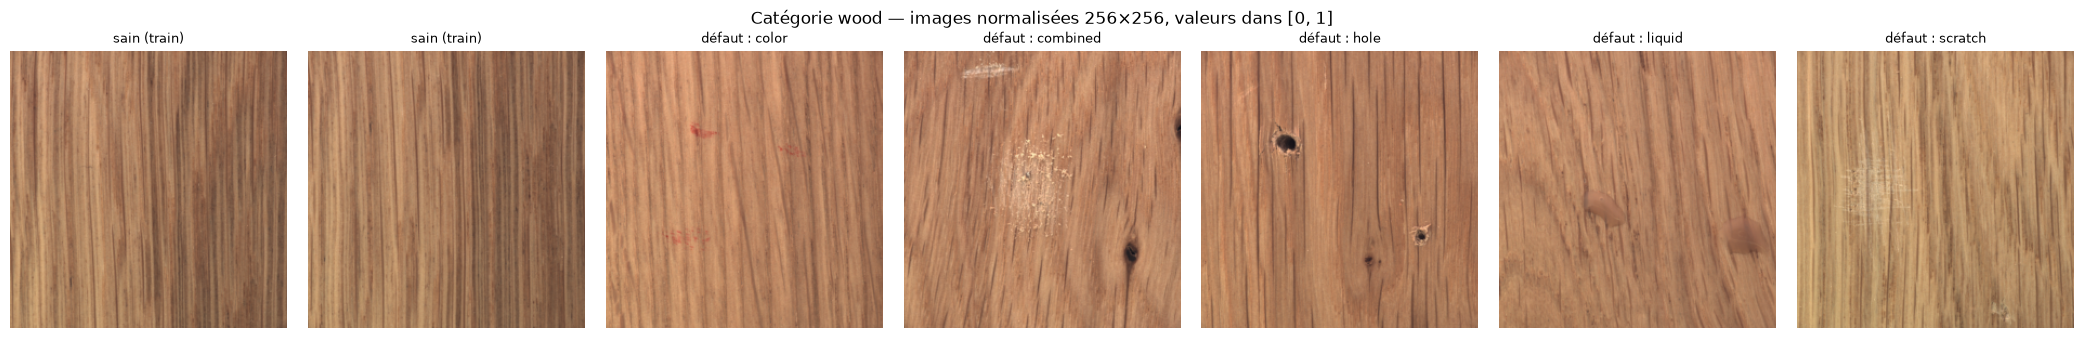

Forme de chaque image : (256, 256, 3), dtype float32
Plage de valeurs observée sur ces échantillons : [0.0667, 0.9961]
CHARGEMENT_NORMALISATION_VALIDE


In [3]:
import matplotlib.pyplot as plt
import numpy as np

from indusense.vision.dataset import load_image

sample_good_paths = train_good_paths[:2]
sample_defect_paths = [test_defect_paths[defect][0] for defect in defect_categories]
sample_paths = sample_good_paths + sample_defect_paths
sample_labels = ['sain (train)'] * len(sample_good_paths) + [f'défaut : {d}' for d in defect_categories]

sample_images = [load_image(path, IMAGE_SIZE) for path in sample_paths]

fig, axes = plt.subplots(1, len(sample_images), figsize=(3 * len(sample_images), 3.4))
for ax, image, label in zip(axes, sample_images, sample_labels):
    ax.imshow(image)
    ax.set_title(label, fontsize=9)
    ax.axis('off')
fig.suptitle(f'Catégorie {CATEGORY} — images normalisées {IMAGE_SIZE}×{IMAGE_SIZE}, valeurs dans [0, 1]')
plt.tight_layout()
plt.show()

pixel_min = min(image.min() for image in sample_images)
pixel_max = max(image.max() for image in sample_images)
print(f'Forme de chaque image : {sample_images[0].shape}, dtype {sample_images[0].dtype}')
print(f'Plage de valeurs observée sur ces échantillons : [{pixel_min:.4f}, {pixel_max:.4f}]')

assert all(image.shape == (IMAGE_SIZE, IMAGE_SIZE, 3) for image in sample_images)
assert 0.0 <= pixel_min and pixel_max <= 1.0
print('CHARGEMENT_NORMALISATION_VALIDE')

## Lecture du résultat précédent : le chargement est-il correct ?

Les 7 images affichées (2 saines d'entraînement + 1 par défaut) ont toutes la forme attendue
**`(256, 256, 3)`** en `float32`. Les valeurs observées sur cet échantillon couvrent **`[0,0667 ;
0,9961]`** : elles restent bien dans `[0, 1]` sans jamais l'atteindre exactement sur ces images
précises (aucun pixel totalement noir ou totalement blanc dans cet échantillon), ce qui est cohérent
avec une normalisation par simple division par 255 (pas de recentrage ni de mise à l'échelle par
canal). L'assertion `CHARGEMENT_NORMALISATION_VALIDE` vérifie mécaniquement ces deux points (forme et
bornes) sur l'échantillon.

Visuellement, `color` (marques rougeâtres) et `hole` (trou sombre net) sont nettement identifiables sur
l'échantillon affiché, `combined` cumule un trou et une zone décolorée. `liquid` et `scratch` sont en
revanche beaucoup plus discrets — une simple variation de teinte ou de reflet, à peine perceptible à
`256×256` — un point à garder en tête pour le réglage du seuil en partie 2 : ces défauts les plus subtils
seront aussi les plus difficiles à détecter par simple erreur de reconstruction.

## Étape 2 — Augmenter les données (Albumentations)

Le pipeline d'augmentation (`indusense.vision.augment.build_augmentation_pipeline`) s'applique **uniquement
aux images saines d'entraînement**. Il combine : symétrie horizontale et verticale, rotation légère
(± 15°), translation/échelle légères et variation de luminosité/contraste. Ces transformations simulent
des variations réalistes de cadrage caméra et d'éclairage en production, sans modifier le contenu
sémantique de l'image (elle doit rester une planche de bois saine).

La cellule suivante applique le pipeline 5 fois à une même image saine et affiche l'original à côté des
versions augmentées.

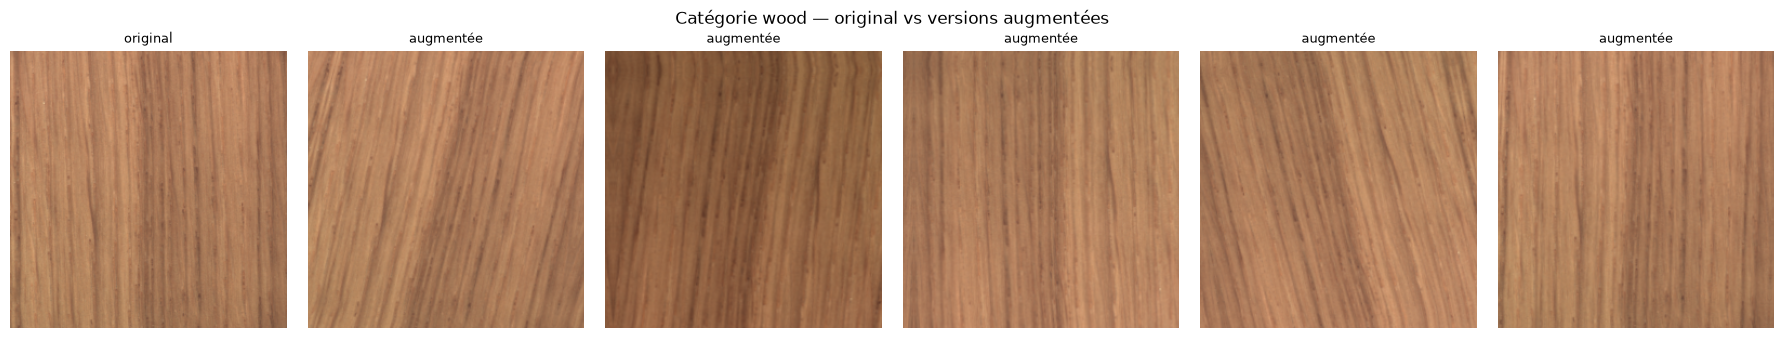

5 versions augmentées générées, forme conservée (256, 256, 3).
AUGMENTATION_VALIDE


In [4]:
from indusense.vision.augment import apply_augmentations, build_augmentation_pipeline

augmentation_pipeline = build_augmentation_pipeline(seed=42)
original_image = load_image(split.train_paths[0], IMAGE_SIZE)
augmented_images = apply_augmentations(original_image, augmentation_pipeline, n_samples=5)

fig, axes = plt.subplots(1, 1 + len(augmented_images), figsize=(3 * (1 + len(augmented_images)), 3.4))
axes[0].imshow(original_image)
axes[0].set_title('original', fontsize=9)
axes[0].axis('off')
for ax, image in zip(axes[1:], augmented_images):
    ax.imshow(np.clip(image, 0.0, 1.0))
    ax.set_title('augmentée', fontsize=9)
    ax.axis('off')
fig.suptitle(f'Catégorie {CATEGORY} — original vs versions augmentées')
plt.tight_layout()
plt.show()

for image in augmented_images:
    assert image.shape == original_image.shape
print(f'{len(augmented_images)} versions augmentées générées, forme conservée {original_image.shape}.')
print('AUGMENTATION_VALIDE')

## Lecture du résultat précédent : les augmentations sont-elles plausibles ?

Les **5** versions augmentées conservent la forme `(256, 256, 3)` (assertion validée) et restent
visuellement crédibles : le grain du bois change légèrement d'angle (rotation ± 15°), la luminosité
varie modérément d'une version à l'autre, et aucune bordure noire artificielle n'apparaît — le
`border_mode` en réflexion (`cv2.BORDER_REFLECT_101`) prolonge la texture au lieu de la tronquer sur fond
noir. Aucune version augmentée ne ressemble à un défaut `hole`, `color`, `combined`, `liquid` ou
`scratch` : les transformations élargissent la variabilité du « normal » sans produire de faux
défauts.

## Point de réflexion : l'augmentation géométrique forte est-elle pertinente pour `wood` ?

`wood` est une **texture** : une planche de bois photographiée n'a pas d'orientation ni de sens de lecture
privilégié. Contrairement à `metal_nut`, où le défaut `flip` désigne une pièce montée à l'envers (un
retournement en augmentation rapprocherait alors une pièce saine de cette configuration défectueuse et
élargirait artificiellement la notion de « normal »), aucun défaut `wood` ne correspond à une orientation
retournée : `color`, `combined`, `hole`, `liquid` et `scratch` restent des défauts locaux (tache, trou,
coulure, rayure) qui existent quelle que soit l'orientation de la planche. Les symétries horizontale et
verticale, ainsi qu'une rotation modérée, sont donc **pertinentes** pour `wood` alors qu'elles seraient
risquées pour `metal_nut`.

Deux précautions restent nécessaires :

- **Rotation limitée à ± 15°** (et non 90°/180°) : au-delà, le grain du bois change d'orientation
  visuelle de façon peu réaliste par rapport aux images de production.
- **Variations de luminosité/contraste modérées** (`± 0.15`) : une variation trop forte pourrait rendre
  invisible un défaut `color` (variation de teinte) sur les images de test, ou au contraire simuler un
  faux défaut sur les images saines d'entraînement — mais comme l'augmentation n'est appliquée qu'aux
  saines d'entraînement (jamais aux images de test), ce risque ne concerne que la définition de « normal »
  apprise par le modèle, pas une fuite vers les défauts.

En résumé, pour un objet centré et orienté (`metal_nut`), l'augmentation géométrique doit être prudente et
exclure les transformations qui imitent un défaut nommé. Pour une texture homogène (`wood`), les mêmes
transformations élargissent utilement la notion de « normal » sans se rapprocher d'un défaut réel.

## Synthèse

- **Étape 1** : `247` images saines d'entraînement et `5` catégories de défauts (`color`, `combined`,
  `hole`, `liquid`, `scratch`) chargées, redimensionnées en `256×256` et normalisées dans `[0, 1]`.
  `15 %` des saines d'entraînement sont réservées à la validation, sans recouvrement.
- **Étape 2** : pipeline Albumentations (flips, rotation ± 15°, translation/échelle légères,
  luminosité/contraste) appliqué uniquement aux saines d'entraînement, retenu car `wood` est une texture
  sans orientation privilégiée — contrairement à `metal_nut`.
- **Reste à valider en partie 2** : ce notebook ne construit ni n'entraîne l'auto-encodeur ; il prépare
  uniquement les données. La qualité du seuil de détection dépendra du jeu de validation constitué ici.